In [119]:
results_folder = '/Users/ondra/LLMEvaluation/PARAMETR-Bench_repo/results'

runs = {"sonnet-public" : "oufl6j",
        "sonnet-private" : "320v4n",
        "geminiPro-public" : "mgglsp",
        "geminiPro-private" : "becqm8",
        "gpt5.4-mini-public" : "2do157",
        "gpt5.4-mini-private" : "mr8u1m",
        "deepseek-private" : "cvxi0a"}

model_names = {
    "anthropic/claude-sonnet-4-6": "Claude Sonnet 4.6",
    "gemini/gemini-3.1-pro-preview": "Gemini 3.1 Pro",
    "openai/gpt-5.4-mini-2026-03-17": "GPT-5.4 Mini",
    "deepinfra/deepseek-ai/DeepSeek-V4-Pro": "DeepSeek V4 Pro"
}

model_colors = {
    "Claude Sonnet 4.6":  "#FF6B35",  # orange
    "Gemini 3.1 Pro":     "#4285F4",  # blue
    "GPT-5.4 Mini":       "#10A37F",  # green
    "DeepSeek V4 Pro":    "#C850C0",  # purple
}

private_seeds = [1042,1043,1044, 1045]
public_seeds = [10, 11, 12, 13]

judge = "haiku-4-5"

In [120]:
import os
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

result_files = {}
all_folders = os.listdir(results_folder)

for run_name, run_string in runs.items():
    matches = [f for f in all_folders if f.startswith(run_string)]
    if not matches:
        print(f"WARNING: no folder found for {run_name!r} ({run_string})")
        continue
    folder_path = os.path.join(results_folder, matches[0])

    json_files = [f for f in os.listdir(folder_path) if f.endswith('.json') and judge in f]
    if not json_files:
        print(f"WARNING: no JSON file with judge {judge!r} found in {matches[0]}")
        continue
    result_files[run_name] = os.path.join(folder_path, json_files[0])

/var/folders/hj/5f4376_j3n1byfzqylrdbbnr0000gn/T/ipykernel_2861/3173610071.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd_data = pd.concat([pd_data, pd.DataFrame({


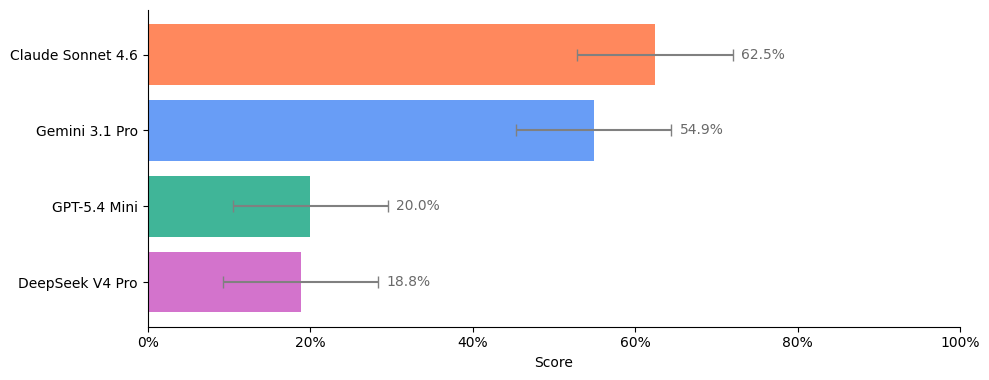

In [121]:
pd_data = pd.DataFrame(columns=['model', 'score', 'ci_low', 'ci_high'])
for results_json in result_files.values():
    with open(results_json, 'r') as f:
        data = json.load(f)
        if data["run"]["seeds"] == private_seeds and data["run"]["difficulty"] == "hard":
            pd_data = pd.concat([pd_data, pd.DataFrame({
                'model': [data["run"]["model"]],
                'score': [data["summary"]["success_rate"]],
                'ci_low': [data["summary"]["ci_low"]],
                'ci_high': [data["summary"]["ci_high"]]
            })], ignore_index=True)

pd_data["model"] = pd_data["model"].map(model_names).fillna(pd_data["model"])
pd_data = pd_data.sort_values(by='score', ascending=False)
labels = pd_data['model'].tolist()
scores  = pd_data['score'].tolist()
err_lo  = [score - ci_low for score, ci_low in zip(scores, pd_data['ci_low'].tolist())]
err_hi  = [ci_high - score for score, ci_high in zip(scores, pd_data['ci_high'].tolist())]
models  = pd_data['model'].tolist()


fig, ax = plt.subplots(figsize=(10, 0.6 * len(labels) + 1.5))

colors = [model_colors.get(m, 'steelblue') for m in labels]
bars = ax.barh(labels, scores, xerr=[err_lo, err_hi],
                capsize=4, color=colors, ecolor='gray', alpha=0.8)

for bar, score, model in zip(bars, scores, models):
    ax.text(bar.get_width() + max(err_hi) + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{score:.1%}', va='center', fontsize=10, color='dimgray')

ax.set_xlabel('Score')
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('assets/images/PARAMETR-Bench/benchmark_results_private.png', dpi=300)
plt.show()


/var/folders/hj/5f4376_j3n1byfzqylrdbbnr0000gn/T/ipykernel_2861/1493659983.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd_data = pd.concat([pd_data, pd.DataFrame({


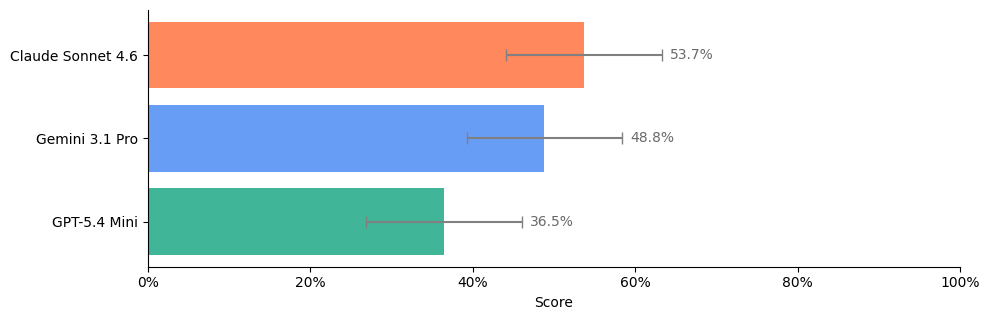

In [122]:
pd_data = pd.DataFrame(columns=['model', 'score', 'ci_low', 'ci_high'])
for results_json in result_files.values():
    with open(results_json, 'r') as f:
        data = json.load(f)
        if data["run"]["seeds"] == public_seeds and data["run"]["difficulty"] == "hard":
            pd_data = pd.concat([pd_data, pd.DataFrame({
                'model': [data["run"]["model"]],
                'score': [data["summary"]["success_rate"]],
                'ci_low': [data["summary"]["ci_low"]],
                'ci_high': [data["summary"]["ci_high"]]
            })], ignore_index=True)

pd_data["model"] = pd_data["model"].map(model_names).fillna(pd_data["model"])
pd_data = pd_data.sort_values(by='score', ascending=False)
labels = pd_data['model'].tolist()
scores  = pd_data['score'].tolist()
err_lo  = [score - ci_low for score, ci_low in zip(scores, pd_data['ci_low'].tolist())]
err_hi  = [ci_high - score for score, ci_high in zip(scores, pd_data['ci_high'].tolist())]
models  = pd_data['model'].tolist()


fig, ax = plt.subplots(figsize=(10, 0.6 * len(labels) + 1.5))

colors = [model_colors.get(m, 'steelblue') for m in labels]
bars = ax.barh(labels, scores, xerr=[err_lo, err_hi],
                capsize=4, color=colors, ecolor='gray', alpha=0.8)

for bar, score, model in zip(bars, scores, models):
    ax.text(bar.get_width() + max(err_hi) + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{score:.1%}', va='center', fontsize=10, color='dimgray')

ax.set_xlabel('Score')
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('assets/images/PARAMETR-Bench/benchmark_results_public.png', dpi=300)
plt.show()


/var/folders/hj/5f4376_j3n1byfzqylrdbbnr0000gn/T/ipykernel_2861/1608343954.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame({
/var/folders/hj/5f4376_j3n1byfzqylrdbbnr0000gn/T/ipykernel_2861/1608343954.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame({


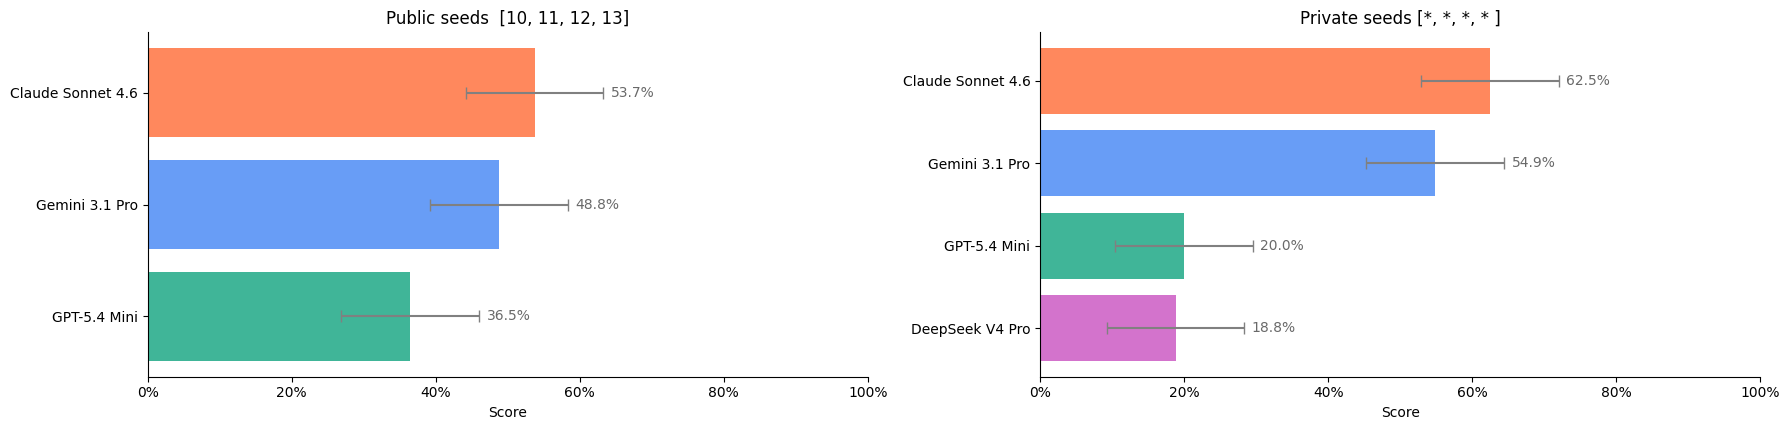

In [123]:
def build_df(result_files, seeds, difficulty="hard"):
    df = pd.DataFrame(columns=['model', 'score', 'ci_low', 'ci_high'])
    for results_json in result_files.values():
        with open(results_json, 'r') as f:
            data = json.load(f)
        if data["run"]["seeds"] == seeds and data["run"]["difficulty"] == difficulty:
            df = pd.concat([df, pd.DataFrame({
                'model':   [data["run"]["model"]],
                'score':   [data["summary"]["success_rate"]],
                'ci_low':  [data["summary"]["ci_low"]],
                'ci_high': [data["summary"]["ci_high"]],
            })], ignore_index=True)
    df["model"] = df["model"].map(model_names).fillna(df["model"])
    return df.sort_values(by='score', ascending=False)

def plot_bars(ax, df, title):
    labels = df['model'].tolist()
    scores = df['score'].tolist()
    err_lo = (df['score'] - df['ci_low']).tolist()
    err_hi = (df['ci_high'] - df['score']).tolist()
    colors = [model_colors.get(m, 'steelblue') for m in labels]
    bars = ax.barh(labels, scores, xerr=[err_lo, err_hi],
                   capsize=4, color=colors, ecolor='gray', alpha=0.8)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + max(err_hi) + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{score:.1%}', va='center', fontsize=10, color='dimgray')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_xlim(0, 1.0)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)

df_public  = build_df(result_files, seeds=public_seeds, difficulty="hard")
df_private = build_df(result_files, seeds=private_seeds)

n_rows = max(len(df_public), len(df_private))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 0.6 * n_rows + 2))

plot_bars(ax1, df_public,  f'Public seeds  {public_seeds}')
plot_bars(ax2, df_private, f'Private seeds [*, *, *, * ]')

plt.tight_layout()
plt.savefig('assets/images/PARAMETR-Bench/benchmark_results_public_private.png', dpi=300)
plt.show()

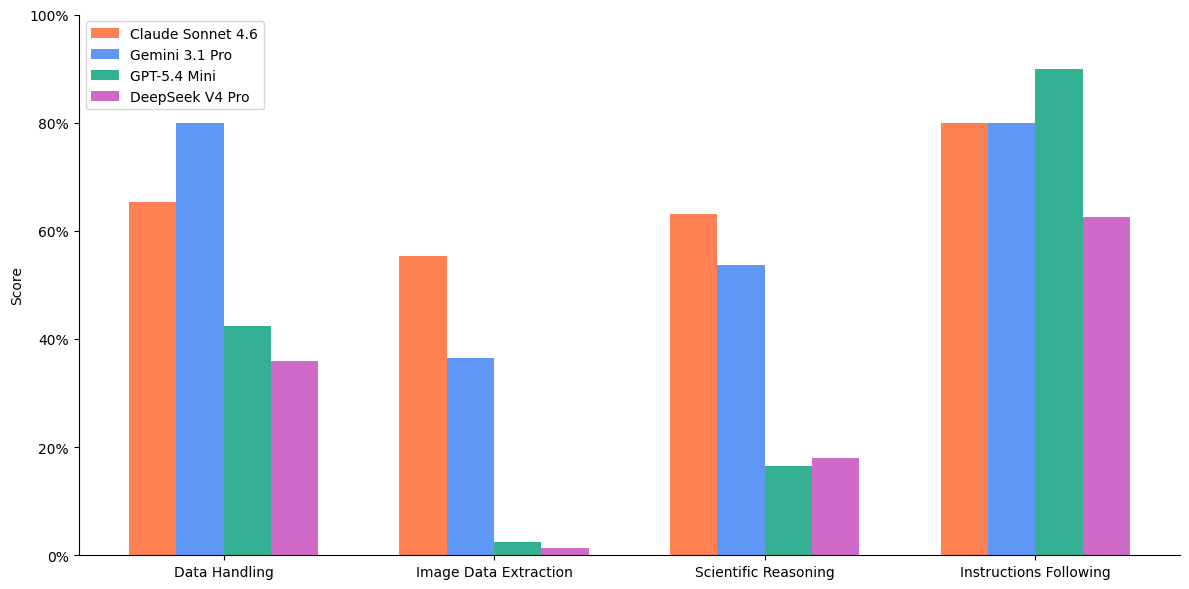

In [124]:
pd_data_dimensions = pd.DataFrame()
for results_json in result_files.values():
    with open(results_json, 'r') as f:
        data = json.load(f)
        if data["run"]["seeds"] == private_seeds:
            pd_data_dimensions = pd.concat([pd_data_dimensions, pd.DataFrame({
                'model': [data["run"]["model"]],
                'data_handling': [data["by_dimension"]["data handling"]["weighted_success_rate"]],
                'image_data_extraction': [data["by_dimension"]["image data extraction"]["weighted_success_rate"]],
                'scientific_reasoning': [data["by_dimension"]["scientific reasoning"]["weighted_success_rate"]],
                'instructions_following': [data["by_dimension"]["instructions following"]["weighted_success_rate"]]
            })], ignore_index=True)

pd_data_dimensions["model"] = pd_data_dimensions["model"].map(model_names).fillna(pd_data_dimensions["model"])
pd_data_dimensions

dimensions  = ['data_handling', 'image_data_extraction', 'scientific_reasoning', 'instructions_following']
dim_labels  = ['Data Handling', 'Image Data Extraction', 'Scientific Reasoning', 'Instructions Following']

models  = pd_data_dimensions['model'].tolist()
n_models = len(models)
x = np.arange(len(dimensions))
width = 0.7 / n_models

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Set2.colors

for i, (_, row) in enumerate(pd_data_dimensions.iterrows()):
    values = [row[d] for d in dimensions]
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, values, width, label=row['model'], color=model_colors.get(row['model'], colors[i]), alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(dim_labels, rotation=0, ha='center')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylabel('Score')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('assets/images/PARAMETR-Bench/benchmark_results_dimensions.png', dpi=300)
plt.show()